# 🎯 7. Self-Correcting RAG

Όλα τα RAG συστήματα που είδαμε μέχρι εδώ είναι **linear**: query → retrieve → generate → done. Αν η ανάκτηση είναι κακή, η απάντηση είναι κακή. Δεν υπάρχει feedback loop.

Σε αυτό το notebook μαθαίνουμε **adaptive** RAG που:

* **Αξιολογεί** τα retrieved docs και αποφασίζει αν είναι αρκετά
* **Επιστρέφει** σε προηγούμενο βήμα αν χρειάζεται (πχ ξανακάνει retrieval με διαφορετικό query)
* **Πέφτει σε web search** όταν το internal corpus δεν αρκεί
* **Ελέγχει** την απάντηση για hallucinations και επανα-γενάει αν χρειάζεται

Δύο σχεδιασμοί που έχουν γίνει standard:

1. **CRAG (Corrective RAG)** — αξιολόγηση docs → fallback σε web search
2. **Self-RAG** — αξιολόγηση generation → επανάληψη ή refinement

Θα τα υλοποιήσουμε με το **LangGraph** — το framework του LangChain για **stateful**, **κυκλικά** workflows.

In [1]:
# !pip install -q langgraph
import os
from pathlib import Path
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# Φορτώνουμε τα API keys από το .env (βρίσκεται στο root του project)
_env_path = Path(".env")
load_dotenv(dotenv_path=_env_path, override=False)

# Αν δεν βρεθεί το key (πχ σε Colab), ζητάμε manually
if not os.environ.get("OPENAI_API_KEY"):
    import getpass
    os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")

LLM_MODEL   = "gpt-4o-mini"
EMBED_MODEL = "text-embedding-3-small"
llm = ChatOpenAI(model=LLM_MODEL, temperature=0)

## 7.1 Setup — η γνωστή knowledge base

In [2]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

REWRITE_PROMPT = ChatPromptTemplate.from_template(
    "The original question did not return relevant results from the Datanous.ai knowledge base. "
    "Rephrase it using different terminology that may better match the available content. "
    "Return only the rewritten question, no explanation.\n\n"
    "Original question: {question}\n\n"
    "Rewritten question:"
)

rewrite_chain = REWRITE_PROMPT | llm | StrOutputParser()

# Test the rewrite chain
test_q = "Which Datanous.ai offering gives me five-nines availability?"
rewritten = rewrite_chain.invoke({"question": test_q})
print(f"Original : {test_q}")
print(f"Rewritten: {rewritten}")


Original : Which Datanous.ai offering gives me five-nines availability?
Rewritten: What Datanous.ai service provides five-nines uptime?


## 7.2 Εισαγωγή στο LangGraph

Το LangGraph μοντελοποιεί RAG flows ως **state machines / graphs**. Κάθε **node** μετασχηματίζει το state, κάθε **edge** καθορίζει τη ροή.

Σε αντίθεση με τα LCEL chains (linear pipelines), το LangGraph υποστηρίζει:

* **Branching** — διαφορετικά μονοπάτια ανάλογα με το state
* **Loops** — επανάληψη βημάτων μέχρι να ικανοποιηθεί κάποια συνθήκη
* **Parallel execution** — πολλά nodes ταυτόχρονα

```
       ┌────────────┐              
       │  retrieve  │              
       └─────┬──────┘              
             │                     
       ┌─────▼──────┐              
       │   grade    │              
       └──┬─────┬───┘              
    relevant   not relevant        
          │          │             
    ┌─────▼──┐  ┌────▼──────┐      
    │generate│  │rewrite_q  │──┐   
    └────────┘  └───────────┘  │   
                       (loop back) 
                                   
```

<img src="images/crag_state_machine.png" width="70%" style="border-radius:10px;margin:12px 0;"/>

***Εικ. 7.1** — CRAG State Machine: retrieve → grade → generate ή rewrite (loop) ή fallback. Τα conditional edges δρομολογούν βάσει του state.*

### Το `State` object

Το state είναι ένα **TypedDict** που περνά από node σε node. Κάθε node επιστρέφει partial updates.

In [3]:
from typing import TypedDict, Literal
# Το TypedDict είναι εργαλείο του Python type system που μας επιτρέπει να ορίσουμε τη δομή ενός dict.
'''
state = {
    "question": "What is Datanous.ai?",
    "rewritten": "",
    "documents": [],
    "answer": "",
    "grade": "relevant",
    "attempts": 0
}
'''
from langchain_core.documents import Document


class RAGState(TypedDict):
    question: str           # Αρχική ερώτηση
    rewritten: str          # Reformulated ερώτηση (αν χρειαστεί)
    documents: list[Document]
    answer: str
    grade: str              # 'relevant' / 'not_relevant'
    attempts: int           # Πόσες φορές κάναμε rewrite

In [4]:
# Επέκταση του RAGState ώστε το graph να μπορεί να ξεκινά μόνο με question + attempts.
try:
    from typing import NotRequired
except ImportError:
    from typing_extensions import NotRequired

class RAGState(TypedDict):
    question: str
    attempts: int
    rewritten: NotRequired[str]
    documents: NotRequired[list[Document]]
    answer: NotRequired[str]
    grade: NotRequired[str]
    context: NotRequired[str]
    hallucination_grade: NotRequired[str]
    answer_grade: NotRequired[str]
    quality_reasoning: NotRequired[str]

## 7.3 CRAG — Corrective RAG

Το CRAG προσθέτει ένα **grading step**: μετά την ανάκτηση, ένα LLM αξιολογεί αν τα docs είναι όντως σχετικά. Αν όχι → ξαναγράφει το query και προσπαθεί ξανά (ή πέφτει σε web search).

### Βήμα 1: Γράφουμε τα nodes

In [5]:
REWRITE_PROMPT = ChatPromptTemplate.from_template(
    "The original question did not return relevant results from the Datanous.ai knowledge base. "
    "Rephrase it using different terminology that may better match the available content. "
    "Return only the rewritten question, no explanation.\n\n"
    "Original question: {question}\n\n"
    "Rewritten question:"
)

rewrite_chain = REWRITE_PROMPT | llm | StrOutputParser()

# Test the rewrite chain
test_q = "Which Datanous.ai offering gives me five-nines availability?"
rewritten = rewrite_chain.invoke({"question": test_q})
print(f"Original : {test_q}")
print(f"Rewritten: {rewritten}")


Original : Which Datanous.ai offering gives me five-nines availability?
Rewritten: What Datanous.ai service provides five-nines uptime?


In [6]:
import re
from collections import Counter
from pydantic import BaseModel, Field

MAX_ATTEMPTS = 2

DATANOUS_KB = [
    Document(
        page_content=(
            "Datanous.ai is an AI-native data platform for document intelligence, "
            "retrieval-augmented generation, agent monitoring, and enterprise knowledge workflows."
        ),
        metadata={"source": "kb/company_overview", "product": "Datanous.ai"},
    ),
    Document(
        page_content=(
            "Datanous Insight Starter costs 49 USD per month. It supports up to 10,000 pages, "
            "basic semantic search, a hosted vector index, and email support."
        ),
        metadata={"source": "kb/insight_starter", "product": "Datanous Insight Starter"},
    ),
    Document(
        page_content=(
            "Datanous Insight Professional costs 350 USD per month, supports up to 100,000 pages, "
            "and includes multi-tenant row-level access control."
        ),
        metadata={"source": "kb/insight_professional", "product": "Datanous Insight Professional"},
    ),
    Document(
        page_content=(
            "Datanous Insight Enterprise includes unlimited document ingestion, custom connectors, "
            "private deployment, SSO/SAML, audit logs, priority onboarding, and a 99.999 percent "
            "uptime SLA for regulated organizations."
        ),
        metadata={"source": "kb/insight_enterprise", "product": "Datanous Insight Enterprise"},
    ),
    Document(
        page_content=(
            "Datanous Guard monitors AI agent actions, enforces policy gates, redacts sensitive data, "
            "logs tool decisions, blocks unsafe tool calls, and sends alerts to administrators."
        ),
        metadata={"source": "kb/datanous_guard", "product": "Datanous Guard"},
    ),
    Document(
        page_content=(
            "Datanous Flow automates recurring data workflows such as ingestion, extraction, validation, "
            "report generation, and routing results to business applications."
        ),
        metadata={"source": "kb/datanous_flow", "product": "Datanous Flow"},
    ),
]

# Offline, dependency-free fallback used to keep this notebook fully runnable without adding Tavily/DuckDuckGo.
# In production, replace this small index with a real web-search tool.
WEB_FALLBACK_DOCS = [
    Document(
        page_content="Brazil's capital is Brasília.",
        metadata={"source": "demo_web/brazil_capital"},
    ),
    Document(
        page_content="CRAG stands for Corrective Retrieval-Augmented Generation.",
        metadata={"source": "demo_web/crag_definition"},
    ),
]

_STOPWORDS = {
    "a", "an", "and", "are", "as", "at", "be", "by", "does", "do", "for", "from",
    "give", "gives", "how", "i", "in", "include", "includes", "is", "it", "me",
    "of", "on", "or", "product", "service", "the", "to", "up", "what", "which",
    "with", "does", "did", "can", "you"
}

def _normalise_query(text: str) -> str:
    text = text.lower()
    replacements = {
        "five-nines": "99.999 uptime sla availability enterprise",
        "five nines": "99.999 uptime sla availability enterprise",
        "five-nines availability": "99.999 uptime sla availability enterprise",
        "availability": "uptime sla",
        "offering": "product service solution",
        "plan": "starter professional enterprise",
        "price": "cost costs pricing",
        "guard": "guard policy monitoring unsafe tool calls",
    }
    for src, dst in replacements.items():
        text = text.replace(src, f"{src} {dst}")
    return text

def _tokens(text: str) -> list[str]:
    text = _normalise_query(text)
    return [
        t for t in re.findall(r"[a-z0-9]+(?:\.[0-9]+)?", text.lower())
        if t not in _STOPWORDS and len(t) > 1
    ]

def _score(query: str, doc: Document) -> float:
    q = Counter(_tokens(query))
    d = Counter(_tokens(doc.page_content + " " + " ".join(str(v) for v in doc.metadata.values())))
    if not q or not d:
        return 0.0
    overlap = sum(min(q[t], d[t]) for t in q)
    # light bonus when important product words match
    important_bonus = sum(1.5 for t in ("datanous", "insight", "enterprise", "starter", "professional", "guard") if q[t] and d[t])
    return overlap + important_bonus

class SimpleDatanousRetriever:
    def __init__(self, documents: list[Document], k: int = 3, min_score: float = 1.0):
        self.documents = documents
        self.k = k
        self.min_score = min_score

    def invoke(self, query: str) -> list[Document]:
        ranked = sorted(
            ((doc, _score(query, doc)) for doc in self.documents),
            key=lambda item: item[1],
            reverse=True,
        )
        return [doc for doc, score in ranked[: self.k] if score >= self.min_score]

retriever = SimpleDatanousRetriever(DATANOUS_KB, k=3)

def demo_web_search(query: str, k: int = 2) -> list[Document]:
    ranked = sorted(
        ((doc, _score(query, doc)) for doc in WEB_FALLBACK_DOCS),
        key=lambda item: item[1],
        reverse=True,
    )
    return [doc for doc, score in ranked[:k] if score >= 1.0]

def format_docs(documents: list[Document]) -> str:
    if not documents:
        return ""
    return "\n\n".join(
        f"[{idx}] Source: {doc.metadata.get('source', 'unknown')}\n{doc.page_content}"
        for idx, doc in enumerate(documents, start=1)
    )

class DocumentGrade(BaseModel):
    """Evaluate whether retrieved documents are useful for answering the question."""
    relevance: Literal["relevant", "not_relevant"] = Field(
        description="Whether the retrieved documents contain information useful for answering the question."
    )
    reasoning: str = Field(description="Brief explanation of the verdict")

DOC_GRADE_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "You are a strict document relevance grader for a Datanous.ai RAG system. "
     "Return 'relevant' only if the context contains information that can help answer the question. "
     "If the context is empty or unrelated, return 'not_relevant'."),
    ("human", "Question:\n{question}\n\nRetrieved context:\n{context}"),
])
document_grader = DOC_GRADE_PROMPT | llm.with_structured_output(DocumentGrade)

GEN_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "You are a precise RAG assistant. Answer only from the provided context. "
     "If the context does not contain the answer, say that the knowledge base does not contain enough information. "
     "Keep the answer concise and factual."),
    ("human", "Question:\n{question}\n\nContext:\n{context}\n\nAnswer:"),
])
generation_chain = GEN_PROMPT | llm | StrOutputParser()

def node_retrieve(state: RAGState) -> dict:
    query = state.get("rewritten") or state["question"]
    docs = retriever.invoke(query)
    print(f"[retrieve] query={query!r} | docs={len(docs)}")
    return {"documents": docs}

def node_grade(state: RAGState) -> dict:
    docs = state.get("documents", [])
    if not docs:
        print("[grade] no documents retrieved → not_relevant")
        return {"grade": "not_relevant"}
    question = state.get("rewritten") or state["question"]
    context = format_docs(docs)
    verdict = document_grader.invoke({"question": question, "context": context})
    print(f"[grade] {verdict.relevance} | {verdict.reasoning}")
    return {"grade": verdict.relevance}

def node_rewrite(state: RAGState) -> dict:
    rewritten = rewrite_chain.invoke({"question": state["question"]}).strip()
    attempts = state.get("attempts", 0) + 1
    print(f"[rewrite] attempt={attempts} | rewritten={rewritten!r}")
    return {"rewritten": rewritten, "attempts": attempts}

def node_generate(state: RAGState) -> dict:
    docs = state.get("documents", [])
    context = format_docs(docs)
    answer = generation_chain.invoke({
        "question": state["question"],
        "context": context,
    }).strip()
    print("[generate] answer generated")
    return {"answer": answer, "context": context}

def node_fallback(state: RAGState) -> dict:
    query = state.get("rewritten") or state["question"]
    web_docs = demo_web_search(query)
    if web_docs:
        context = format_docs(web_docs)
        answer = generation_chain.invoke({
            "question": state["question"],
            "context": context,
        }).strip()
        print("[fallback] answered using demo web-search fallback")
        return {"documents": web_docs, "context": context, "answer": answer}
    print("[fallback] no internal or demo-web evidence found")
    return {
        "answer": (
            "I could not find enough relevant information in the Datanous.ai knowledge base "
            "or the demo web-search fallback to answer this question."
        ),
        "context": "",
    }

def decide_after_grade(state: RAGState) -> str:
    if state.get("grade") == "relevant":
        return "generate"
    if state.get("attempts", 0) < MAX_ATTEMPTS:
        return "rewrite"
    return "fallback"

### Βήμα 2: Συναρμολόγηση του graph

In [7]:
from langgraph.graph import StateGraph, START, END

workflow = StateGraph(RAGState)

# Add nodes
workflow.add_node("retrieve",  node_retrieve)
workflow.add_node("grade",     node_grade)
workflow.add_node("rewrite",   node_rewrite)
workflow.add_node("generate",  node_generate)
workflow.add_node("fallback",  node_fallback)

# Edges
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade")
workflow.add_conditional_edges(
    "grade",
    decide_after_grade,
    {"generate": "generate", "rewrite": "rewrite", "fallback": "fallback"},
)
workflow.add_edge("rewrite", "retrieve")   # retry loop
workflow.add_edge("generate", END)
workflow.add_edge("fallback", END)

crag = workflow.compile()
print("CRAG graph compiled successfully.")


CRAG graph compiled successfully.


/home/kleidimos/coding-factory/AI_for_developers/venv/lib/python3.12/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [8]:
# Test 1: question fully covered by the Datanous.ai knowledge base
print("=== Test 1: in-corpus question ===")
result = crag.invoke({
    "question": "What does Datanous Insight Enterprise include?",
    "attempts": 0,
})
print("Answer:", result["answer"])


=== Test 1: in-corpus question ===
[retrieve] query='What does Datanous Insight Enterprise include?' | docs=3
[grade] relevant | The first retrieved context directly lists the features included in Datanous Insight Enterprise, which answers the question.
[generate] answer generated
Answer: Datanous Insight Enterprise includes unlimited document ingestion, custom connectors, private deployment, SSO/SAML, audit logs, priority onboarding, and a 99.999 percent uptime SLA for regulated organizations.


In [9]:
# Test 2: question with unusual vocabulary that may need rewriting
print("\n=== Test 2: tricky vocabulary ===")
result = crag.invoke({
    "question": "Which Datanous.ai product gives me five-nines availability?",
    "attempts": 0,
})
print("Answer:", result["answer"])



=== Test 2: tricky vocabulary ===
[retrieve] query='Which Datanous.ai product gives me five-nines availability?' | docs=3
[grade] relevant | The context from the first source specifically mentions that Datanous Insight Enterprise offers a 99.999 percent uptime SLA, which corresponds to five-nines availability.
[generate] answer generated
Answer: Datanous Insight Enterprise provides five-nines availability with a 99.999 percent uptime SLA.


In [10]:
# Test 3: question completely outside the Datanous.ai knowledge base
print("\n=== Test 3: out-of-scope question ===")
result = crag.invoke({
    "question": "What is the capital of Brazil?",
    "attempts": 0,
})
print("Answer:", result["answer"])



=== Test 3: out-of-scope question ===
[retrieve] query='What is the capital of Brazil?' | docs=0
[grade] no documents retrieved → not_relevant
[rewrite] attempt=1 | rewritten='What city serves as the capital of Brazil?'
[retrieve] query='What city serves as the capital of Brazil?' | docs=0
[grade] no documents retrieved → not_relevant
[rewrite] attempt=2 | rewritten='What city serves as the capital of Brazil?'
[retrieve] query='What city serves as the capital of Brazil?' | docs=0
[grade] no documents retrieved → not_relevant
[fallback] answered using demo web-search fallback
Answer: Brazil's capital is Brasília.


## 7.4 Web search fallback

Στο πλήρες CRAG, αντί για απλό fallback, μπορεί να γίνει **web search** όταν το internal corpus αποτυγχάνει.

In [11]:
# Demo του fallback μηχανισμού χωρίς επιπλέον βιβλιοθήκες.
for web_q in [
    "What is the capital of Brazil?",
    "What is a CRAG pipeline?",
]:
    docs = demo_web_search(web_q)
    print(f"\nQuery: {web_q}")
    print(format_docs(docs) if docs else "No fallback result found.")


Query: What is the capital of Brazil?
[1] Source: demo_web/brazil_capital
Brazil's capital is Brasília.

Query: What is a CRAG pipeline?
[1] Source: demo_web/crag_definition
CRAG stands for Corrective Retrieval-Augmented Generation.


In [12]:
from pydantic import BaseModel, Field
from typing import Literal

class HallucinationGrade(BaseModel):
    """Evaluate whether all claims in an answer are grounded in the context."""
    grounded:  Literal["yes", "no"] = Field(description="Are all claims supported by the context?")
    reasoning: str                  = Field(description="Brief explanation of the verdict")

HALL_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "Check whether ALL claims in the answer are supported by the context. "
     "If the answer contains any claim not found in the context, return 'no'."),
    ("human", "Context:\n{context}\n\nAnswer:\n{answer}"),
])
hallucination_grader = HALL_PROMPT | llm.with_structured_output(HallucinationGrade)

# Demo: a fabricated answer vs the real Datanous.ai knowledge base content
fabricated_answer = (
    "Datanous Insight Professional costs 1,200 USD per month and supports "
    "unlimited pages with a 99.999 percent uptime SLA."
)
real_context = (
    "Datanous Insight Professional costs 350 USD per month, supports up to 100,000 pages, "
    "and includes multi-tenant row-level access control."
)

result = hallucination_grader.invoke({"context": real_context, "answer": fabricated_answer})
print(f"Grounded : {result.grounded}")
print(f"Reasoning: {result.reasoning}")


Grounded : no
Reasoning: The answer contains incorrect claims about the cost, page support, and uptime SLA of Datanous Insight Professional, which are not supported by the context.


## 7.5 Self-RAG — αξιολόγηση της απάντησης

Το **Self-RAG** προσθέτει ακόμα ένα step μετά την παραγωγή: αξιολογεί αν η απάντηση:

* **Είναι grounded** στο context (no hallucination)
* **Όντως απαντά** στην ερώτηση

Αν όχι → επανα-γενεάει με διορθωτικές οδηγίες.

### Hallucination grader

In [ ]:
from pydantic import BaseModel, Field
from typing import Literal

class HallucinationGrade(BaseModel):
    """Evaluate whether all claims in an answer are grounded in the context."""
    grounded:  Literal["yes", "no"] = Field(description="Are all claims supported by the context?")
    reasoning: str                  = Field(description="Brief explanation of the verdict")

HALL_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "Check whether ALL claims in the answer are supported by the context. "
     "If the answer contains any claim not found in the context, return 'no'."),
    ("human", "Context:\n{context}\n\nAnswer:\n{answer}"),
])
hallucination_grader = HALL_PROMPT | llm.with_structured_output(HallucinationGrade)

# Demo: a fabricated answer vs the real Datanous.ai knowledge base content
fabricated_answer = (
    "Datanous Insight Professional costs 1,200 USD per month and supports "
    "unlimited pages with a 99.999 percent uptime SLA."
)
real_context = (
    "Datanous Insight Professional costs 350 USD per month, supports up to 100,000 pages, "
    "and includes multi-tenant row-level access control."
)

result = hallucination_grader.invoke({"context": real_context, "answer": fabricated_answer})
print(f"Grounded : {result.grounded}")
print(f"Reasoning: {result.reasoning}")


Grounded : no
Reasoning: The answer contains incorrect claims about the cost, page support, and uptime SLA of Datanous Insight Professional, which are not supported by the context.


### Answer grader (όντως απαντά;)

In [13]:
class AnswerGrade(BaseModel):
    """Evaluate whether the answer actually addresses the user question."""
    addresses: Literal["yes", "no"] = Field(
        description="Does the answer address what the question asked?"
    )

ANS_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "Evaluate whether the answer actually addresses the user question. "
     "Example: an answer about uptime when asked about price does NOT address the question → 'no'."),
    ("human", "Question: {question}\n\nAnswer: {answer}"),
])
answer_grader = ANS_PROMPT | llm.with_structured_output(AnswerGrade)

# Demo
q      = "How much does Datanous Insight Professional cost?"
bad_a  = "Datanous Insight Enterprise has a 99.9 percent uptime SLA."
good_a = "Datanous Insight Professional costs 350 USD per month."

for label, ans in [("Off-topic answer", bad_a), ("Correct answer", good_a)]:
    grade = answer_grader.invoke({"question": q, "answer": ans})
    print(f"{label}: addresses={grade.addresses}  | {ans[:70]}")


Off-topic answer: addresses=no  | Datanous Insight Enterprise has a 99.9 percent uptime SLA.
Correct answer: addresses=yes  | Datanous Insight Professional costs 350 USD per month.


### Πλήρες Self-RAG graph

In [ ]:
class AnswerGrade(BaseModel):
    """Evaluate whether the answer actually addresses the user question."""
    addresses: Literal["yes", "no"] = Field(
        description="Does the answer address what the question asked?"
    )

ANS_PROMPT = ChatPromptTemplate.from_messages([
    ("system",
     "Evaluate whether the answer actually addresses the user question. "
     "Example: an answer about uptime when asked about price does NOT address the question → 'no'."),
    ("human", "Question: {question}\n\nAnswer: {answer}"),
])
answer_grader = ANS_PROMPT | llm.with_structured_output(AnswerGrade)

# Demo
q      = "How much does Datanous Insight Professional cost?"
bad_a  = "Datanous Insight Enterprise has a 99.9 percent uptime SLA."
good_a = "Datanous Insight Professional costs 350 USD per month."

for label, ans in [("Off-topic answer", bad_a), ("Correct answer", good_a)]:
    grade = answer_grader.invoke({"question": q, "answer": ans})
    print(f"{label}: addresses={grade.addresses}  | {ans[:70]}")


Off-topic answer: addresses=no  | Datanous Insight Enterprise has a 99.9 percent uptime SLA.
Correct answer: addresses=yes  | Datanous Insight Professional costs 350 USD per month.


In [14]:
def node_quality_check(state: RAGState) -> dict:
    context = state.get("context") or format_docs(state.get("documents", []))
    answer = state.get("answer", "")

    if not context or not answer:
        return {
            "hallucination_grade": "no",
            "answer_grade": "no",
            "quality_reasoning": "Missing context or answer.",
        }

    hall = hallucination_grader.invoke({"context": context, "answer": answer})
    ans = answer_grader.invoke({"question": state["question"], "answer": answer})
    reasoning = f"grounded={hall.grounded}; addresses={ans.addresses}; hallucination_reasoning={hall.reasoning}"
    print(f"[quality_check] {reasoning}")

    return {
        "hallucination_grade": hall.grounded,
        "answer_grade": ans.addresses,
        "quality_reasoning": reasoning,
    }

def decide_after_quality(state: RAGState) -> str:
    if state.get("hallucination_grade") == "yes" and state.get("answer_grade") == "yes":
        return "end"
    if state.get("attempts", 0) < MAX_ATTEMPTS:
        return "rewrite"
    return "fallback"

self_rag_workflow = StateGraph(RAGState)

self_rag_workflow.add_node("retrieve", node_retrieve)
self_rag_workflow.add_node("grade", node_grade)
self_rag_workflow.add_node("rewrite", node_rewrite)
self_rag_workflow.add_node("generate", node_generate)
self_rag_workflow.add_node("quality_check", node_quality_check)
self_rag_workflow.add_node("fallback", node_fallback)

self_rag_workflow.add_edge(START, "retrieve")
self_rag_workflow.add_edge("retrieve", "grade")
self_rag_workflow.add_conditional_edges(
    "grade",
    decide_after_grade,
    {"generate": "generate", "rewrite": "rewrite", "fallback": "fallback"},
)
self_rag_workflow.add_edge("rewrite", "retrieve")
self_rag_workflow.add_edge("generate", "quality_check")
self_rag_workflow.add_conditional_edges(
    "quality_check",
    decide_after_quality,
    {"end": END, "rewrite": "rewrite", "fallback": "fallback"},
)
self_rag_workflow.add_edge("fallback", END)

self_rag = self_rag_workflow.compile()
print("Self-RAG graph compiled successfully.")

for q in [
    "What does Datanous Guard do?",
    "What is the price of Datanous Insight Starter?",
]:
    print(f"\n=== Self-RAG test: {q} ===")
    result = self_rag.invoke({"question": q, "attempts": 0})
    print("Answer:", result["answer"])

Self-RAG graph compiled successfully.

=== Self-RAG test: What does Datanous Guard do? ===
[retrieve] query='What does Datanous Guard do?' | docs=3
[grade] relevant | The first retrieved context directly describes the functions of Datanous Guard, detailing its role in monitoring AI actions, enforcing policies, and managing sensitive data.
[generate] answer generated
[quality_check] grounded=yes; addresses=yes; hallucination_reasoning=All claims in the answer are directly supported by the context provided in Source [1].
Answer: Datanous Guard monitors AI agent actions, enforces policy gates, redacts sensitive data, logs tool decisions, blocks unsafe tool calls, and sends alerts to administrators.

=== Self-RAG test: What is the price of Datanous Insight Starter? ===
[retrieve] query='What is the price of Datanous Insight Starter?' | docs=3
[grade] relevant | The context provides the specific price of Datanous Insight Starter, which directly answers the question.
[generate] answer genera

## 7.6 Visualizing the graph

Το LangGraph μπορεί να σου δώσει mermaid diagram του compiled graph.

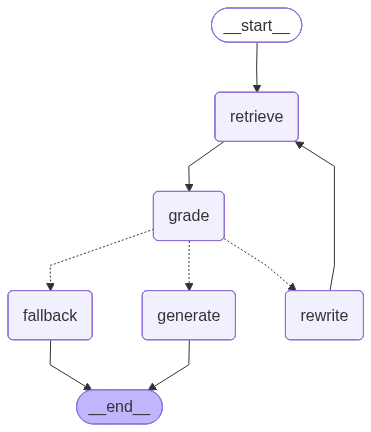

In [15]:
# Visualise the CRAG graph (requires Mermaid support in Jupyter)
from IPython.display import Image, display
display(Image(crag.get_graph().draw_mermaid_png()))

# Text-based Mermaid output (works in any environment)
# print(crag.get_graph().draw_mermaid())


## 7.7 Πότε να χρησιμοποιήσεις τι

| Pattern | Χρειάζεσαι όταν |
|---|---|
| **Naive RAG** | Απλό use case, σταθερή ποιότητα retrieval |
| **CRAG** | Ποικίλες ερωτήσεις, μερικές εκτός corpus |
| **Self-RAG** | Ζητάμε υψηλή αξιοπιστία (πχ medical, legal, financial) |
| **Hybrid (CRAG + Self-RAG + web fallback)** | Production assistant για end users |

**Cost:** Κάθε self-correction loop = +2-3 LLM calls. Σε production μπορείς να κάνεις:
* **Threshold strategy:** μόνο για ερωτήσεις που το embedding similarity score είναι χαμηλό
* **Confidence-based routing:** εφάρμοσε self-RAG μόνο σε high-stakes queries

## 7.8 Άσκηση

**Άσκηση:** Επέκτεινε το CRAG ώστε στο `node_rewrite` να μην παράγει **μία** εκδοχή της ερώτησης, αλλά **τρεις διαφορετικές** (όπως στο Multi-Query του notebook 03), και στο `node_retrieve` να κάνει retrieval και για τις 3 και να παίρνει union.

In [ ]:
# Exercise: Extend the CRAG pipeline with an answer quality check.
#
# After node_generate produces an answer, add a new node "quality_check" that:
# 1. Uses hallucination_grader to verify the answer is grounded in the context.
# 2. Uses answer_grader to verify the answer addresses the question.
# 3. If both pass → END.
# 4. If hallucination_grader says "no" → rewrite and retry (back to "retrieve").
# 5. If answer_grader says "no" and attempts < 2 → rewrite and retry.
# 6. If attempts >= 2 → fallback.
#
# Update RAGState to include an "answer" field and a "context" field.
# Test with: "What does Datanous Guard do?"
#            "What is the price of Datanous Insight Starter?"

# Your solution here:


In [ ]:
# Reference run for the exercise using the completed Self-RAG graph above.
for q in [
    "What does Datanous Guard do?",
    "What is the price of Datanous Insight Starter?",
]:
    print(f"\nExercise test: {q}")
    result = self_rag.invoke({"question": q, "attempts": 0})
    print("Answer:", result["answer"])

In [ ]:
# Visualise the CRAG graph (requires Mermaid support in Jupyter)
# from IPython.display import Image, display
# display(Image(crag.get_graph().draw_mermaid_png()))

# Text-based Mermaid output (works in any environment)
print(crag.get_graph().draw_mermaid())


## 📋 Συμπεράσματα

| # | Έννοια | Συνοπτικά |
|---|---|---|
| 1 | Linear RAG limit | Δεν υπάρχει feedback — αν retrieval αποτύχει, η απάντηση αποτυγχάνει |
| 2 | LangGraph | Stateful, κυκλικό workflow framework πάνω στο LangChain |
| 3 | State | TypedDict που περνά από node σε node |
| 4 | Conditional edges | Δρομολογούν ροή βάσει του state |
| 5 | CRAG | grade docs → retry με rewrite ή fallback |
| 6 | Web fallback | Όταν το KB δεν αρκεί → DuckDuckGo / Tavily |
| 7 | Self-RAG | grade απάντησης (grounded; addresses;) |
| 8 | Hallucination grader | Έλεγχος ότι κάθε claim είναι grounded |
| 9 | Loop guard | Πάντα `MAX_ATTEMPTS` για να αποφύγεις infinite loops |
| 10 | Cost trade-off | +2-3 LLM calls ανά correction loop |
| 11 | Επόμενο βήμα | Notebook 08 — Evaluation & Production |